In [5]:
import os
import sys
from pathlib import Path

import torch
from torch.utils.data import DataLoader

sys.path.append("/share/home/e2406754/cde_mt/WildfireSpreadTSPlus")

from src.dataloader.FireSpreadDataset import FireSpreadDataset
from src.models.UTAELightningRabina import UTAELightningRabina
import json

Initializing dataset...


/share/home/e2406754/.conda/envs/cde_mt_3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/share/home/e2406754/.conda/envs/cde_mt_3.12/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [6]:
def split_within_year_fires(year_id, json_path):
    """
    Load train/val/test event IDs from a JSON file for a specific year.

    Args:
        year_id (int or str): The year to get splits for, e.g., 2016
        json_path (str or Path): Path to the JSON file

    Returns:
        train_event_ids (list): List of training event IDs for the year
        val_event_ids (list): List of validation event IDs for the year
        test_event_ids (list): List of test event IDs for the year
    """
    json_path = Path(json_path)
    if not json_path.is_file():
        raise FileNotFoundError(f"JSON file not found: {json_path}")

    with open(json_path, "r") as f:
        data = json.load(f)

    # Convert year_id to string since JSON keys are strings
    year_key = str(year_id)

    train_event_ids = data.get("train_event_ids", {}).get(year_key, [])
    val_event_ids   = data.get("val_event_ids", {}).get(year_key, [])
    test_event_ids  = data.get("test_event_ids", {}).get(year_key, [])

    return train_event_ids, val_event_ids, test_event_ids

Loading HDF5 files
True [2016] do_cross_year_experimentdo_cross_year_experimentdo_cross_year_experimentdo_cross_year_experiment
Using cross years experiment related stats
computing missing_values for pos_class_weight, cross-year experimentation
Using temporal_position_mode =  relative
Using loss function =  BCE
Using positive class weight =  565.8416
Using device =  cpu

 Using Threshold in metric calculation: 0.5

 Using temporal_position_mode relative

 Using encoder_weights: pastis
Checkpoint loaded successfully from '/share/home/e2406754/cde_mt/WildfireSpreadTSPlus/lightning_logs/cross_year_train_ecol2l3_debug/utae_train_2018_posweight20/wildfire_progression/jqak9tz2/checkpoints/best-epoch=42-val_avg_precision=0.43.ckpt'
Best threshold from validation PR curve: 0.9580389
Best F1 score: 0.31490786770259654


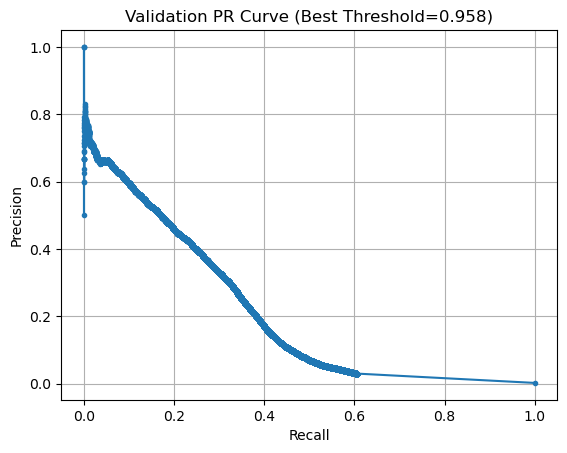

In [7]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# === Settings ===
CKPT_PATH = "/share/home/e2406754/cde_mt/WildfireSpreadTSPlus/lightning_logs/cross_year_train_ecol2l3_debug/utae_train_2018_posweight20/wildfire_progression/jqak9tz2/checkpoints/best-epoch=42-val_avg_precision=0.43.ckpt"
DATA_DIR = "/share/home/e2406754/cde_mt/CDE_Master_Thesis_Wildfire_CL/data/processed/WSTS_all_hdf5_optimized"
YEAR = 2016
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# === Load validation split ===
split_json_path = "/share/home/e2406754/cde_mt/CDE_Master_Thesis_Wildfire_CL/output/data_split/cross_year_spatial_eco_l2l3_split.json"
train_event_ids, val_event_ids, _ = split_within_year_fires(YEAR, split_json_path)

# === Build validation dataset ===
ds = FireSpreadDataset(
    data_dir=DATA_DIR,
    included_fire_years=[YEAR],
    n_leading_observations=5,
    crop_side_length=128,
    load_from_hdf5=True,
    is_train=False,
    remove_duplicate_features=False,
    stats_years=[YEAR],
    return_doy=True,
    do_cross_year_experiment=True,
    include_event_ids=val_event_ids,
)

loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)

# === Load model ===
model_kwargs = {
    'n_channels': 40,
    'pos_class_weight': 565.8416,
    'encoder_weights': 'pastis',
    'temporal_position_mode': 'relative',
    'pretrained_checkpoint_path': CKPT_PATH,
    'loss_function': 'BCE',
    'flatten_temporal_dimension': False,
    'crop_before_eval': False
}

model = UTAELightningRabina(**model_kwargs)
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model = model.to(DEVICE).eval()

# === Collect predictions and labels ===
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        if len(batch) == 3:
            x, y, doys = batch
            x, doys = x.to(DEVICE), doys.to(DEVICE)
            y_hat = torch.sigmoid(model(x, doys).squeeze(1))
        else:
            x, y = batch
            x = x.to(DEVICE)
            y_hat = torch.sigmoid(model(x).squeeze(1))

        all_probs.append(y_hat.cpu())
        all_labels.append(y.cpu())

# === Flatten tensors ===
all_probs = torch.cat(all_probs).numpy().ravel()
all_labels = torch.cat(all_labels).numpy().ravel()

# === Compute PR curve ===
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# === Find best threshold (F1) ===
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("Best threshold from validation PR curve:", best_threshold)
print("Best F1 score:", f1_scores[best_idx])

# === Plot PR curve ===
plt.figure()
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Validation PR Curve (Best Threshold={best_threshold:.3f})")
plt.grid()
plt.show()

In [10]:
CKPT_PATH = "/share/home/e2406754/cde_mt/WildfireSpreadTSPlus/lightning_logs/cross_year_train_ecol2l3_debug/utae_train_2018_posweight20/wildfire_progression/jqak9tz2/checkpoints/best-epoch=42-val_avg_precision=0.43.ckpt"
DATA_DIR = "/share/home/e2406754/cde_mt/CDE_Master_Thesis_Wildfire_CL/data/processed/WSTS_all_hdf5_optimized"

YEAR = 2016
STATS_YEAR = 2018
EVENT_ID = "fire_19662454"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Build dataset for one event only
ds = FireSpreadDataset(
    data_dir=DATA_DIR,
    included_fire_years=[YEAR],
    n_leading_observations=5,
    crop_side_length=128,
    load_from_hdf5=True,
    is_train=False,
    remove_duplicate_features=False,
    stats_years=[STATS_YEAR],
    return_doy=True,
    include_event_ids=[EVENT_ID],
    do_cross_year_experiment=True,
)

print("dataset len:", len(ds))

loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)
# === Load model ===
model_kwargs = {
    'n_channels': 40,
    'pos_class_weight': 565.8416,
    'encoder_weights': 'pastis',
    'temporal_position_mode': 'relative',
    'pretrained_checkpoint_path': CKPT_PATH,
    'loss_function': 'BCE',
    'flatten_temporal_dimension': False,
    'crop_before_eval': False
}
model = UTAELightningRabina(**model_kwargs)
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model = model.to(DEVICE).eval()

predictions = []
targets = []
inputs = []
doys_all = []

with torch.no_grad():
    for batch in loader:
        x, y, doys = batch
        x = x.to(DEVICE)
        doys = doys.to(DEVICE)

        y_hat = model(x, doys).squeeze(1)          # [B, H, W]
        y_prob = torch.sigmoid(y_hat)

        predictions.append(y_prob.cpu())
        targets.append(y.cpu())
        inputs.append(x.cpu())
        doys_all.append(doys.cpu())

print("num windows:", len(predictions))
print("prediction shape of first window:", predictions[0].shape)


Loading HDF5 files
True [2018] do_cross_year_experimentdo_cross_year_experimentdo_cross_year_experimentdo_cross_year_experiment
Using cross years experiment related stats
computing missing_values for pos_class_weight, cross-year experimentation
dataset len: 28
Using temporal_position_mode =  relative
Using loss function =  BCE
Using positive class weight =  565.8416
Using device =  cpu

 Using Threshold in metric calculation: 0.5

 Using temporal_position_mode relative

 Using encoder_weights: pastis
Checkpoint loaded successfully from '/share/home/e2406754/cde_mt/WildfireSpreadTSPlus/lightning_logs/cross_year_train_ecol2l3_debug/utae_train_2018_posweight20/wildfire_progression/jqak9tz2/checkpoints/best-epoch=42-val_avg_precision=0.43.ckpt'
num windows: 28
prediction shape of first window: torch.Size([1, 128, 128])


In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_binary_predictions(predictions, n_cols=5):
    """
    Plot all predicted windows as binary maps (0=white, 1=black).
    
    Args:
        predictions: list of torch.Tensor or numpy arrays, each [1, H, W] or [H, W]
        n_cols: number of columns in the grid
    """
    n_preds = len(predictions)
    n_rows = int(np.ceil(n_preds / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, pred in enumerate(predictions):
        # Convert to numpy if tensor
        if hasattr(pred, "cpu"):
            pred = pred.cpu().numpy()

        # Remove channel dimension if it exists
        if pred.ndim == 3 and pred.shape[0] == 1:
            pred = pred[0]  # shape now [H, W]

        # Convert probabilities to binary (0 or 1)
        pred_bin = (pred > 0.958).astype(int)

        ax = axes[i]
        # Use binary colormap: 0=white, 1=black
        im = ax.imshow(pred_bin, cmap='gray_r')  # gray_r reverses gray: 1=black
        ax.set_title(f"Window {i+1}")
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0,1])
        ax.set_xticks([])
        ax.set_yticks([])

    # Turn off extra axes
    for j in range(n_preds, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()



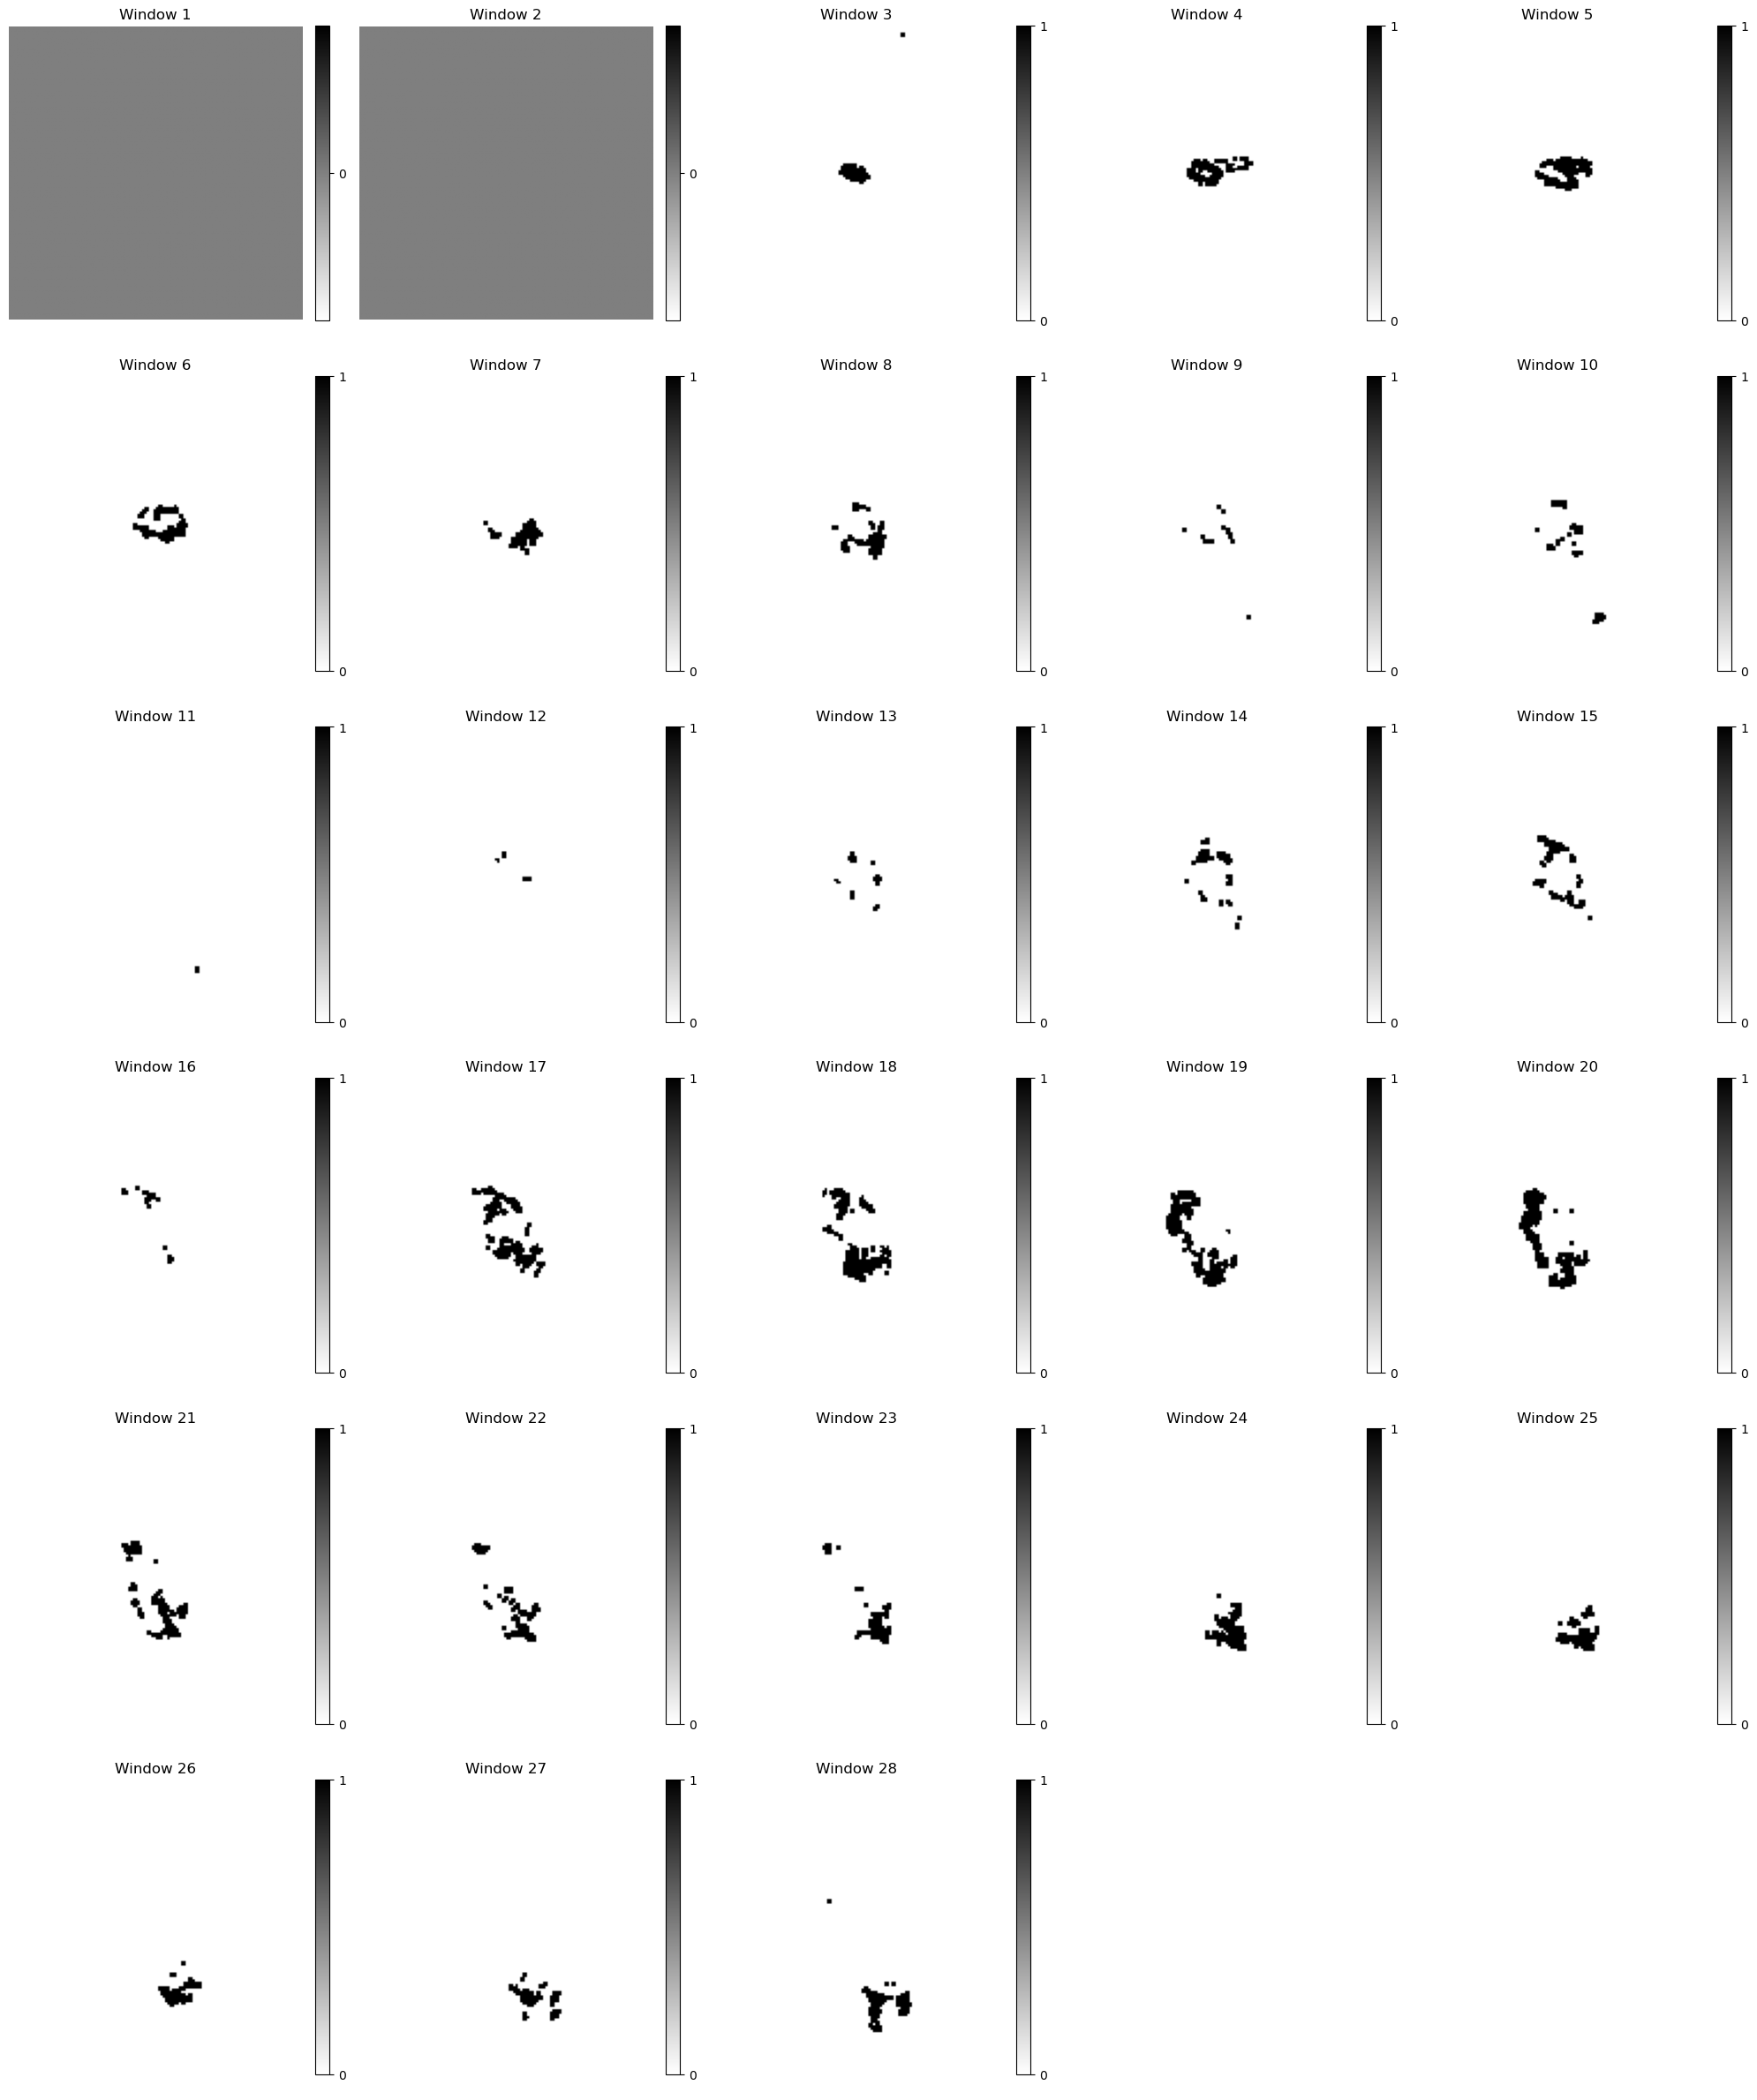

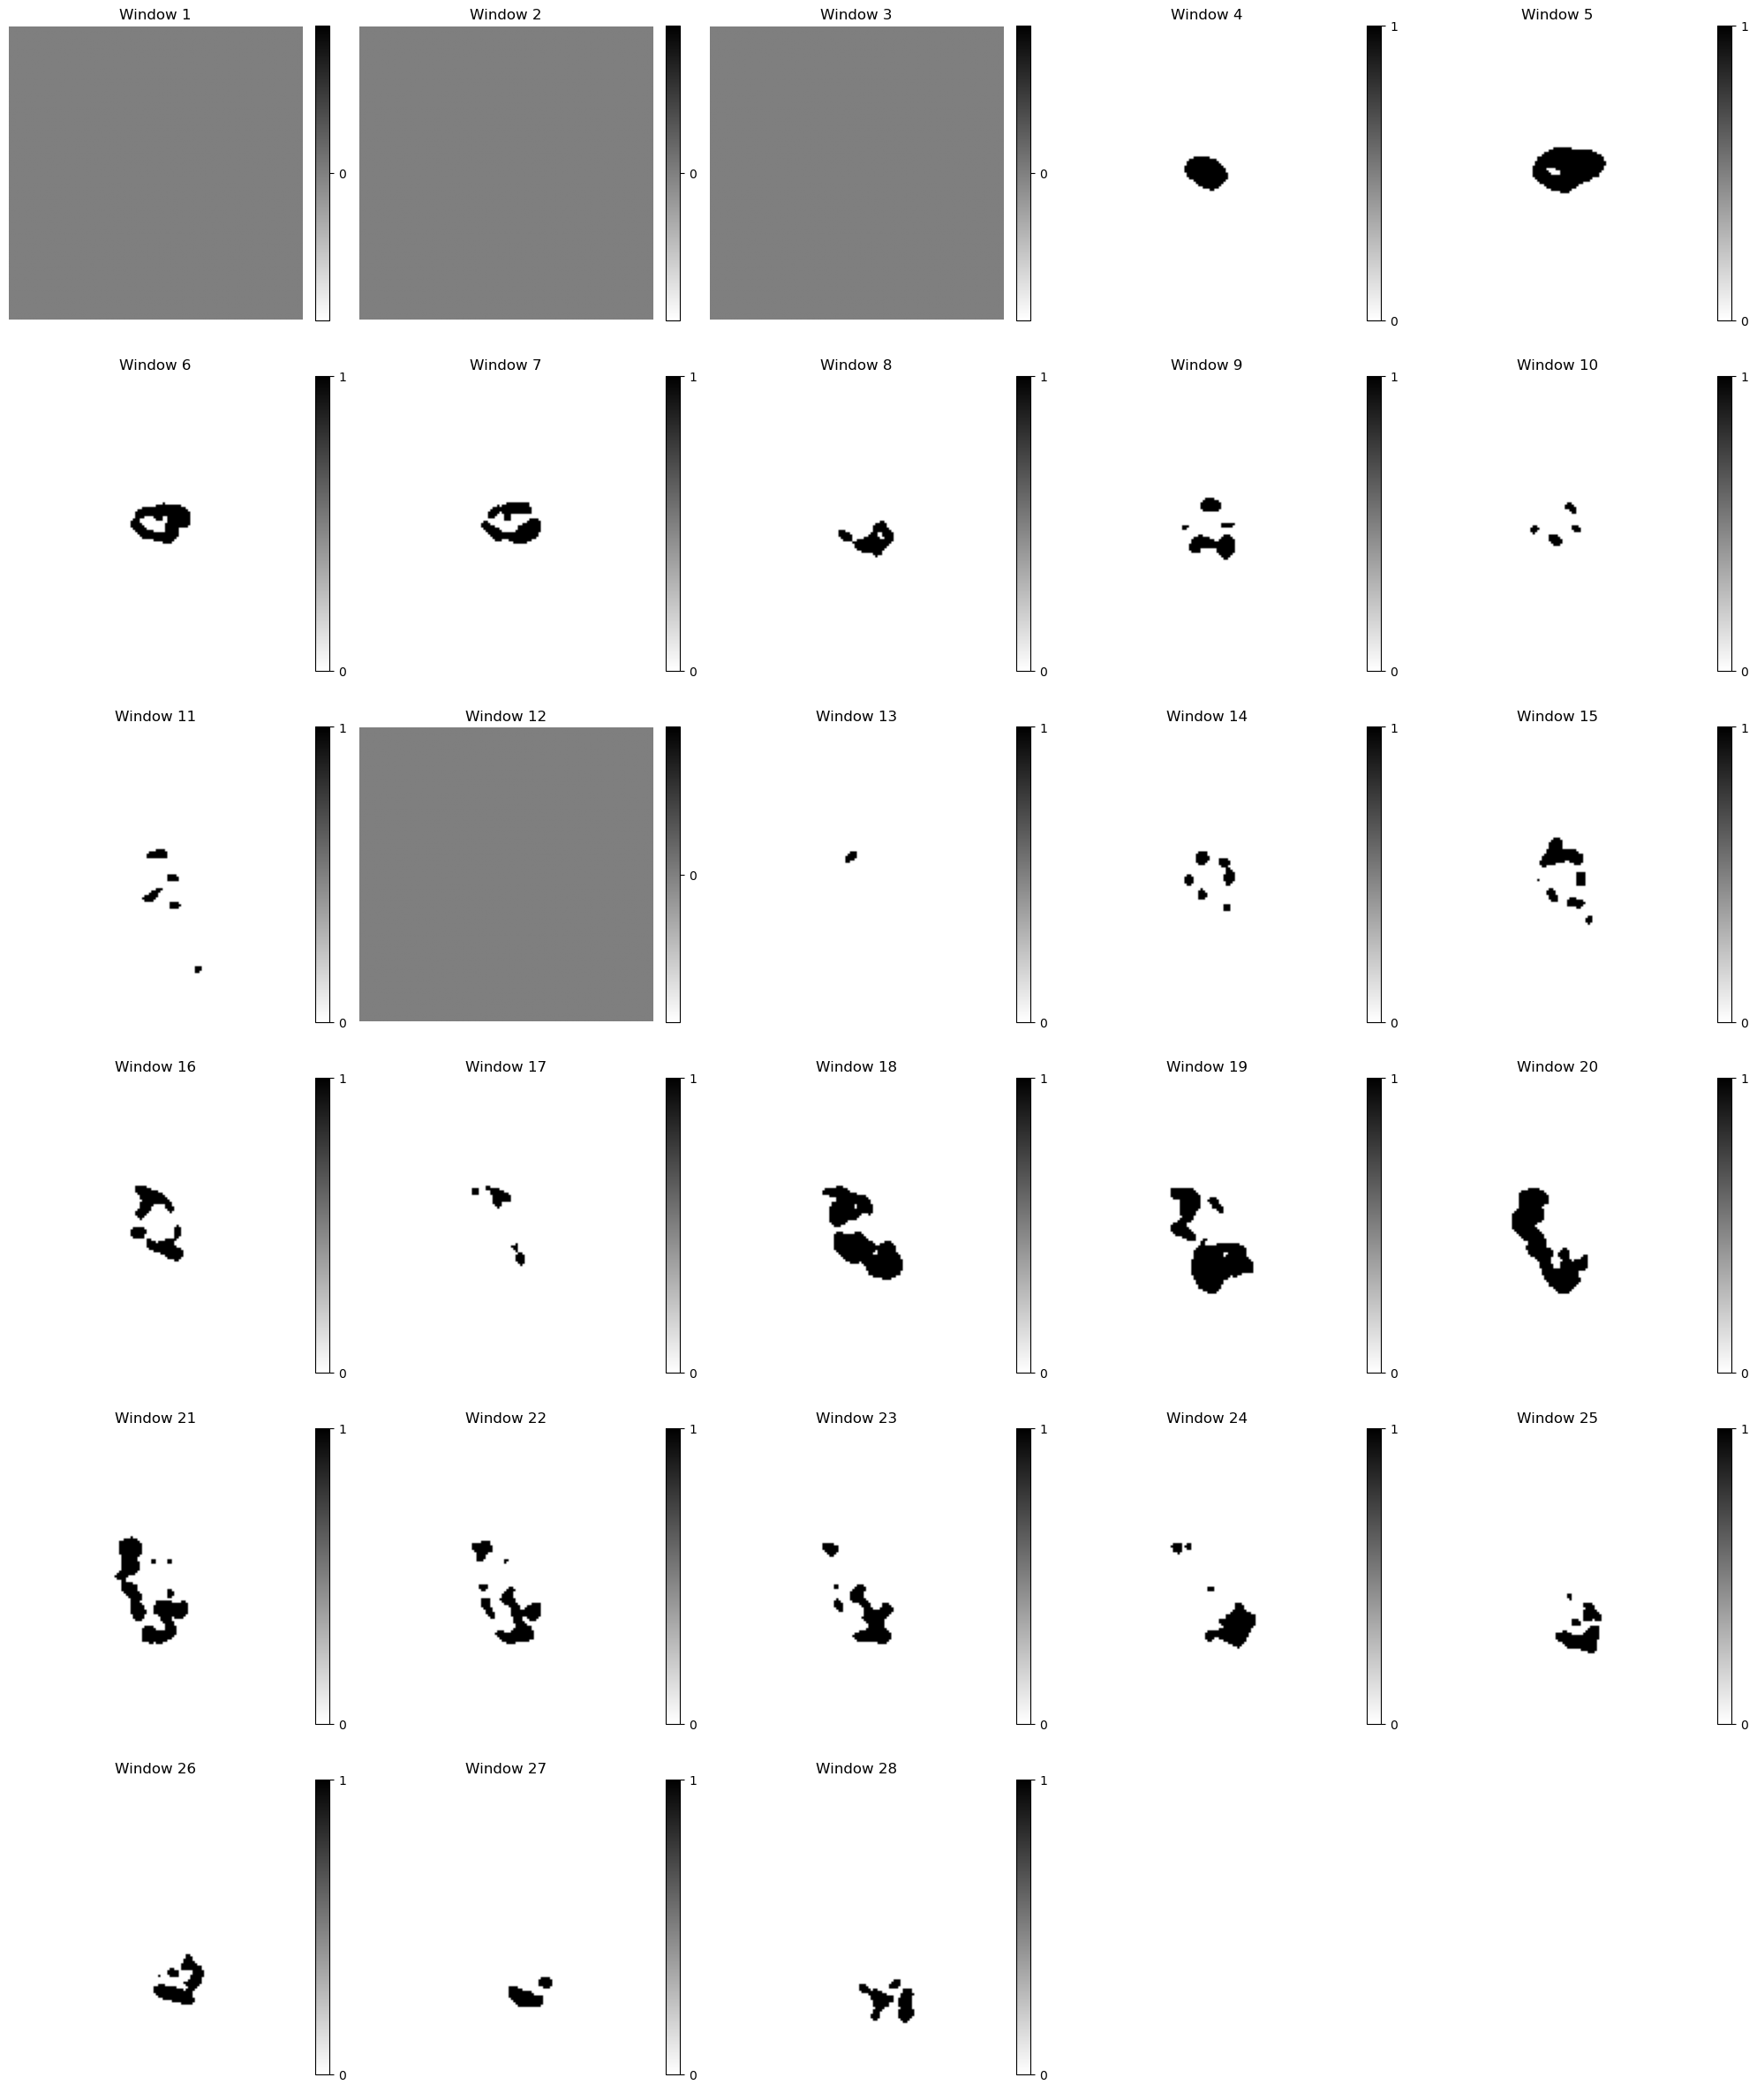

In [12]:
# Call the function
plot_binary_predictions(targets, n_cols=5)
plot_binary_predictions(predictions, n_cols=5)

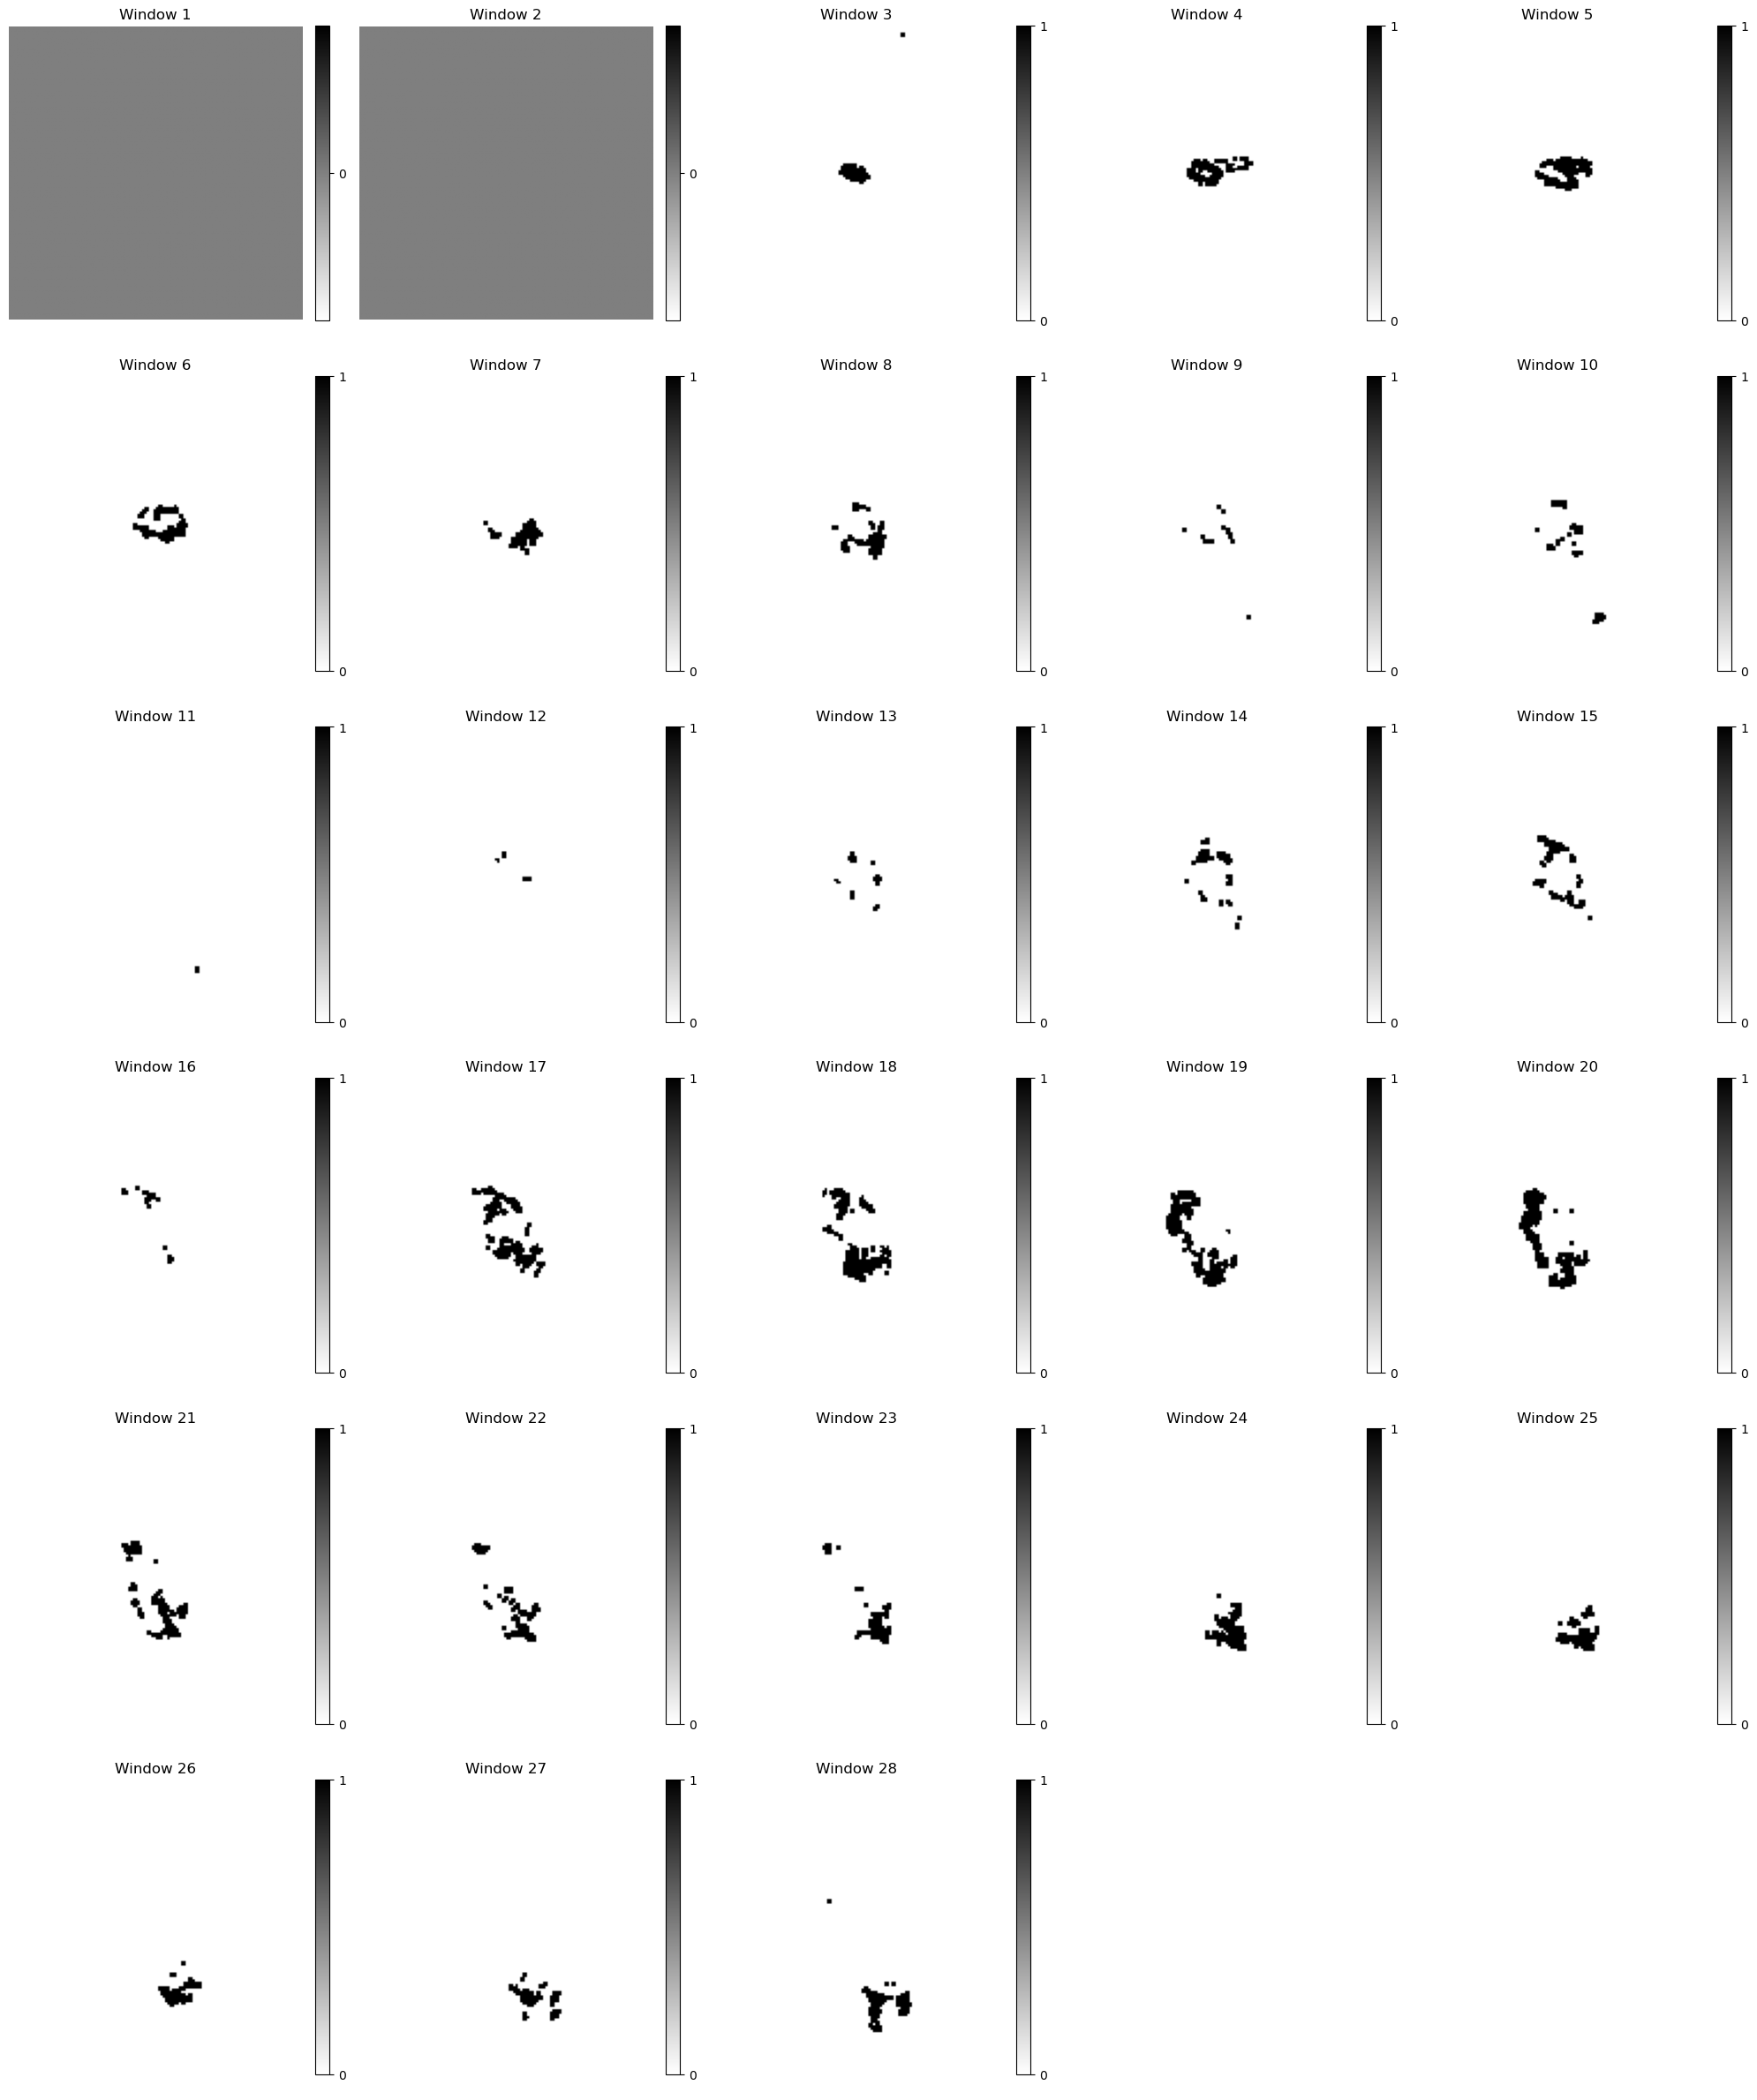

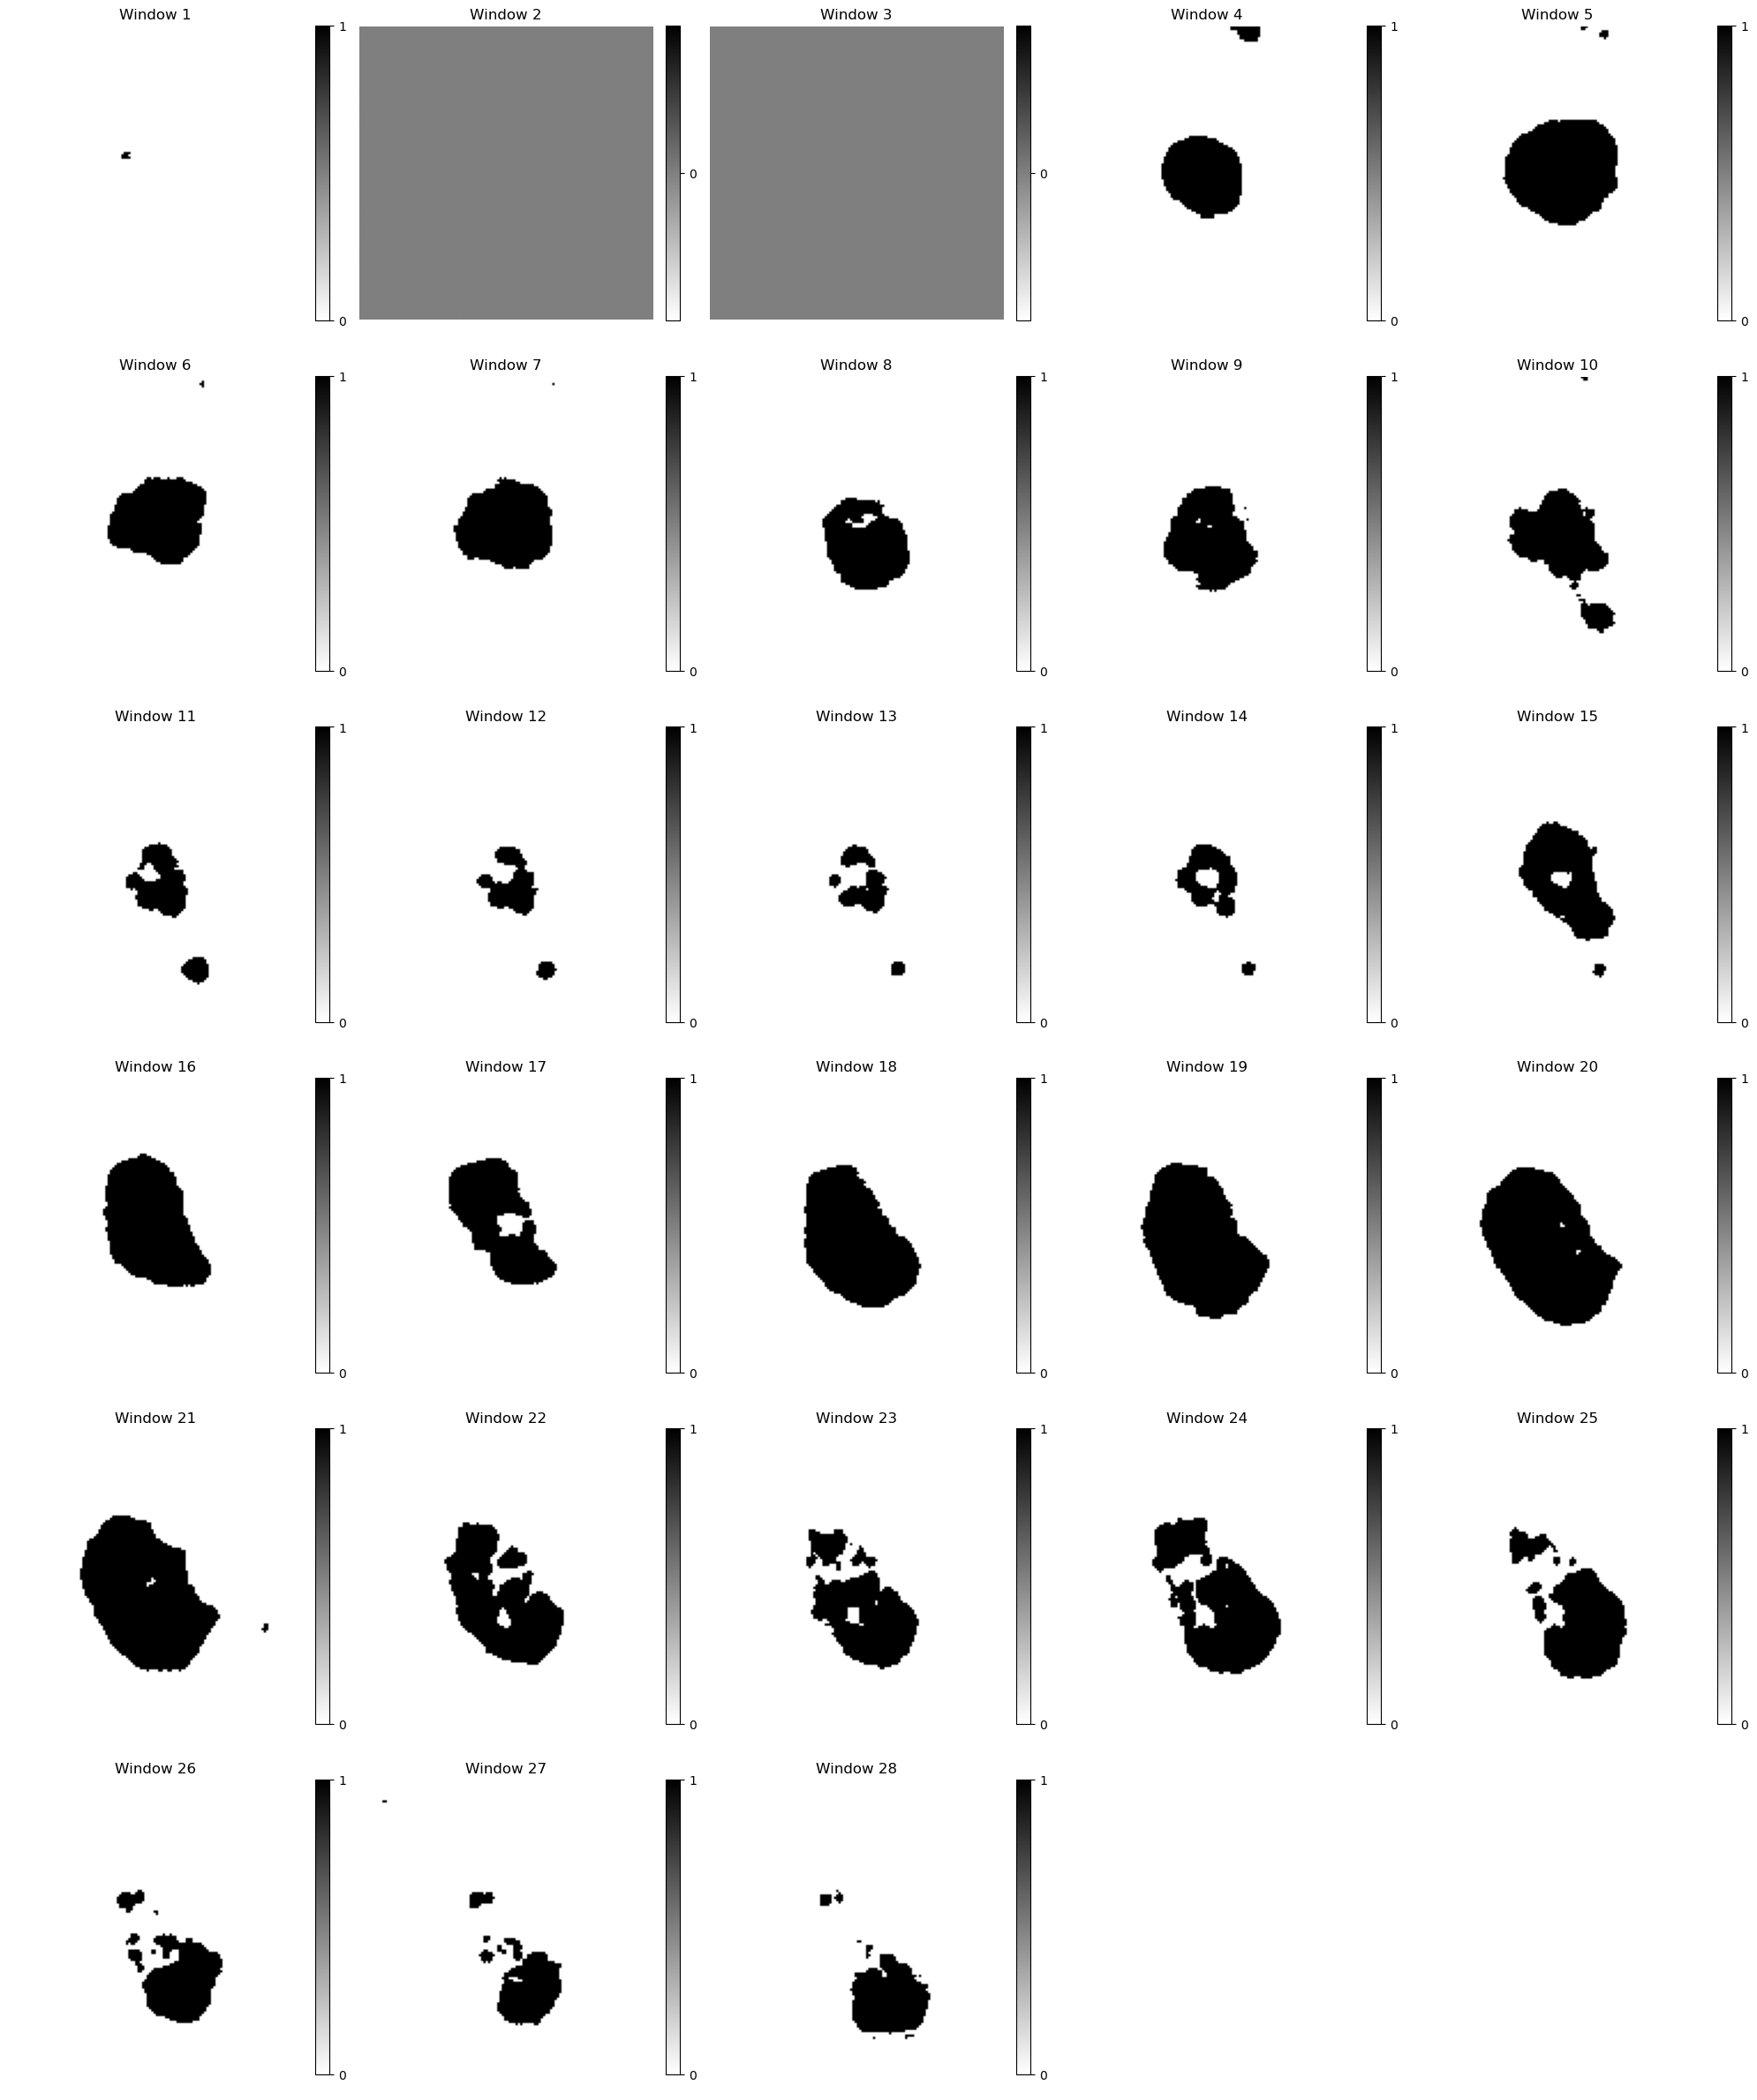

In [8]:
# Call the function
plot_binary_predictions(targets, n_cols=5)
plot_binary_predictions(predictions, n_cols=5)
